In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Getting the dataset from UCI Machine Learning Repository
df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data', header=None)

# Saving the dataset locally as CSV
df_wine.to_csv('wine.csv', index=False)

# Check the data
df = pd.read_csv('wine.csv')

# Display the first few rows of the dataframe
df.head()


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [2]:
print("Dataset shape:", df.shape)

Dataset shape: (178, 14)


In [4]:
# Data Preprocessing
# Separate features and target variable

X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Feature Scaling
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.fit_transform(X_test)

# calculating the covariance matrix
cov_mat = np.cov(X_train_std.T)
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)

# Displaying the eigenvalues and eigenvectors
print('\nEigenvalues \n%s' % eigen_vals)
print('\nEigenvectors \n%s' % eigen_vecs)


Eigenvalues 
[4.8923083  2.46635032 1.42809973 1.01233462 0.84906459 0.60181514
 0.52251546 0.08414846 0.33051429 0.29595018 0.16831254 0.21432212
 0.2399553 ]

Eigenvectors 
[[ 1.46698114e-01  5.04170789e-01 -1.17235150e-01  2.06254611e-01
  -1.87815947e-01 -1.48851318e-01 -1.79263662e-01 -5.54687162e-02
  -4.03054922e-01 -4.17197583e-01  2.75660860e-01  4.03567189e-01
   4.13320786e-04]
 [-2.42245536e-01  2.42168894e-01  1.49946576e-01  1.30489298e-01
   5.68639776e-01 -2.69052764e-01 -5.92636731e-01  3.32731614e-02
  -1.01833706e-01  2.17101488e-01 -8.13845005e-02 -1.52474999e-01
  -8.78560762e-02]
 [-2.99344215e-02  2.86984836e-01  6.56394387e-01  1.51536318e-02
  -2.99209426e-01 -9.33386061e-02  6.07334578e-02 -1.00618575e-01
   3.51841423e-01  1.28549846e-01 -1.29751275e-02  1.68376064e-01
  -4.52518598e-01]
 [-2.55190023e-01 -6.46871827e-02  5.84282337e-01 -9.04220851e-02
  -4.12499478e-02 -1.01342392e-01  2.50323869e-01  5.61658566e-02
  -5.00457282e-01  4.73344124e-02  9.8908

In [5]:
# Calculating the total variance

tot = sum(eigen_vals)
var_exp = [(i / tot) for i in  sorted(eigen_vals, reverse=True)]

cum_var_exp = np.cumsum(var_exp)
print('\nVariance Explained \n%s' % var_exp)
print('\nCumulative Variance Explained \n%s' % cum_var_exp)


Variance Explained 
[np.float64(0.37329647723490683), np.float64(0.18818926106599557), np.float64(0.10896790724757795), np.float64(0.07724389477124854), np.float64(0.0647859460182618), np.float64(0.04592013811478149), np.float64(0.03986935597634704), np.float64(0.025219142607261533), np.float64(0.02258180681767966), np.float64(0.018309244719526892), np.float64(0.016353362655051457), np.float64(0.012842705837492759), np.float64(0.006420756933868292)]

Cumulative Variance Explained 
[0.37329648 0.56148574 0.67045365 0.74769754 0.81248349 0.85840362
 0.89827298 0.92349212 0.94607393 0.96438317 0.98073654 0.99357924
 1.        ]


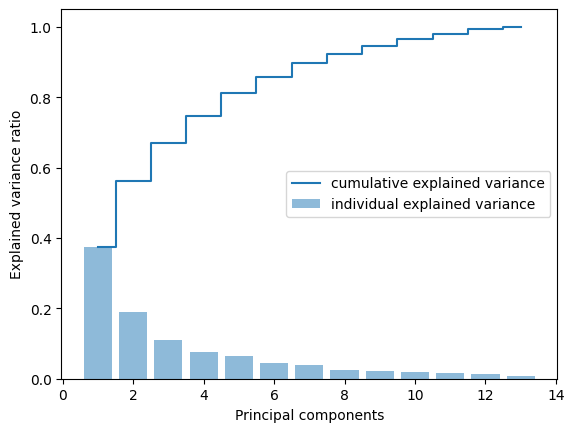

: 

In [ ]:
# Plotting the explained variance
import matplotlib.pyplot as plt

plt.bar(range(1,14), 
        var_exp, alpha=0.5, 
        align='center',  
        label='individual explained variance')

plt.step(range(1,14), 
         cum_var_exp, where='mid',  
         label='cumulative explained variance')

plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc='best')
plt.show()